# Arm comparison — L2-SP vs ANIL vs the lookup

In [2]:
import sys, json, pathlib, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

_SRC = pathlib.Path.cwd()
for _ in range(6):
    if (_SRC / "ProVoice").is_dir():
        break
    _SRC = _SRC.parent
sys.path.insert(0, str(_SRC))

# Imported, never re-derived: the lookup must be the SAME rule as baseline_lookup.py
# and the metrics the SAME as everywhere else, or "the gap to the lookup" is a gap to
# something else and "set-MAE" means two things in one thesis.
from ProVoice.training_scripts.baseline_lookup import (
    best_constant, build_table, load_labels, predict,
)
from ProVoice.models.train_XLSTM import set_accuracy as set_acc_, set_mae as set_mae_

%matplotlib inline
pd.set_option("display.width", 220)
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = _SRC.parent
CMP = ROOT / "results/arm_comparison_v2"
LABELS_CSV = ROOT / "data/study1_data/user_loa_labels.csv"
VAL_FRAC = 0.3        # MUST match the --val-frac the comparison ran with
K_CAP = 60            # above this, driver coverage collapses -- see below
GRAD_OK = 1e-3        # sweep_l2sp_tau.GRAD_NORM_WARN

ARMS = {"l2sp": "L2-SP (population init)", "anil": "ANIL (meta-learned init)"}
COL = {"l2sp": "tab:blue", "anil": "tab:red", "lookup": "k", "floor": "0.45"}

A = {}
for arm in ARMS:
    f = CMP / arm / "l2sp_tau_sweep.csv"
    d = pd.read_csv(f, dtype={"pid": str})
    d["arm"] = arm
    A[arm] = d
    print(f"{arm:5s}: {len(d):4d} rows | tau {sorted(d.tau.unique())} | "
          f"head_in {sorted(d.head_in.unique())} | embed_fcd {sorted(d.embed_fcd.unique())} | "
          f"converged {(d.grad_norm <= GRAD_OK).mean():.1%}")

D = pd.concat(A.values(), ignore_index=True)
SUMMARY = json.loads((CMP / "arm_comparison.json").read_text())
KS = sorted(D.k.unique())

# ARM SYMMETRY, checked rather than trusted: the whole comparison rests on the two
# arms differing ONLY in theta_init.
for col in ("tau", "head_in", "embed_fcd", "n_val"):
    per = {a: sorted(d[col].unique()) for a, d in A.items()}
    same = per["l2sp"] == per["anil"]
    print(f"  {col:10s} {'MATCH' if same else 'DIFFER -> ' + str(per)}")
assert set(A["l2sp"].pid) == set(A["anil"].pid), "arms scored different drivers"
print(f"\nsummary: {SUMMARY}")

# ---- figure export ---------------------------------------------------------
# Vector PDF for the thesis, written alongside the inline display so the
# notebook stays readable and the figure files cannot drift from it.
FIGDIR = ROOT / "latex" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)
FIGPREFIX = "arms"
plt.rcParams["pdf.fonttype"] = 42      # embed TrueType; Type 3 is rejected by
                                       # some submission systems and renders
                                       # poorly when the PDF is scaled.


def save(fig, name: str) -> None:
    """Write ``<FIGDIR>/<name>.pdf``. Tight bbox so LaTeX sees no dead margin."""
    p = FIGDIR / f"{name}.pdf"
    fig.savefig(p, format="pdf", bbox_inches="tight")
    print(f"[fig] {p}")


l2sp :  218 rows | tau [1.0] | head_in [76] | embed_fcd [1] | converged 99.5%
anil :  218 rows | tau [1.0] | head_in [76] | embed_fcd [1] | converged 100.0%
  tau        MATCH
  head_in    MATCH
  embed_fcd  MATCH
  n_val      MATCH

summary: {'tau': 1.0, 'k_cap': 60, 'unadapted_floor_set_mae': 1.498551309775164, 'n_drivers': 12, 'mean_mae_delta_anil_minus_l2sp': 0.02058333333333333, 'se': 0.04782750228422424, 'wilcoxon_p': 0.6220703125, 'anil_better_on': 6, 'verdict': 'indistinguishable (|delta| < 1 SE)', 'caveats': []}


---
## 1. The K curves

Mean over drivers at each K, with a 1-SE band from the between-driver spread. Both
arms, the deployable **driver x function lookup**, and **both** unadapted floors.

Only K <= 60 is shaded as the reporting region: all 12 drivers reach it, while 75 is
reached by 11 and 90 by only 3 (007, 009, 010). A mean at K=90 would be those three
drivers, not the cohort, so the grey region is drawn but must not be quoted.

lookup: 12 drivers x 19 K


**Driver coverage per K** — why only K <= 60 is quotable

k,1,2,3,4,5,6,8,10,12,14,16,20,25,30,40,50,60,75,90
drivers,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,11,3


[fig] c:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\latex\figures\arms_k_curve_set_mae.pdf


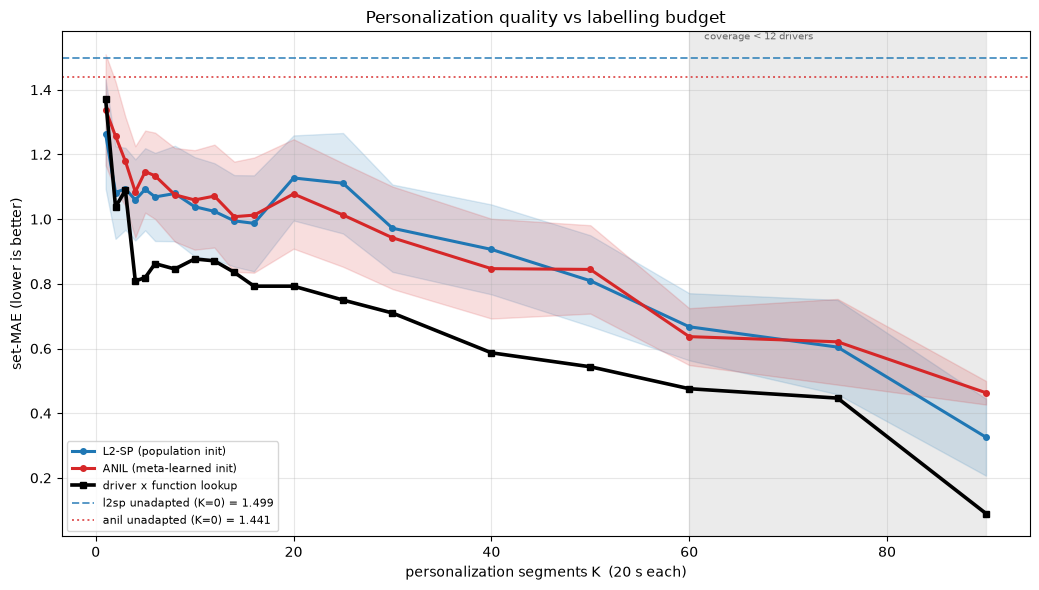

In [3]:
# ---- the lookup, recomputed on the SAME protocol the arms were scored on

def lookup_on_sweep_protocol(labels_csv, ks, val_frac, variant="driver_function",
                             min_cell=1) -> pd.DataFrame:
    """Per-(driver, function) lookup: support = first K, query = last val_frac.

    Identical split to sweep_l2sp_tau.sweep_driver, so the lookup and the two arms
    are measured on the very same query rows and can be differenced per cell.
    """
    lab = load_labels(labels_csv)
    out = []
    for pid, g in lab.groupby("participantid"):
        g = g.reset_index(drop=True)
        n = len(g)
        n_val = max(1, round(val_frac * n))
        pool, query = g.iloc[: n - n_val], g.iloc[n - n_val:]
        q_lv = np.stack(query["marks"].to_numpy())
        for k in ks:
            if k > len(pool):
                continue
            table, driver_c = build_table(pool.iloc[:k], min_cell)
            if driver_c is None:
                continue
            pred, _ = predict(query, table, driver_c, variant)
            out.append({"pid": str(pid), "k": int(k),
                        "set_mae": float(set_mae_(q_lv, pred)),
                        "set_acc": float(set_acc_(q_lv, pred))})
    return pd.DataFrame(out)


LK = lookup_on_sweep_protocol(LABELS_CSV, KS, VAL_FRAC)
print(f"lookup: {LK.pid.nunique()} drivers x {LK.k.nunique()} K")

COVER = D[D.arm == "l2sp"].groupby("k").pid.nunique()
display(Markdown("**Driver coverage per K** — why only K <= %d is quotable" % K_CAP))
display(COVER.to_frame("drivers").T)


def curve(df, col):
    """mean, se and n over drivers at each K."""
    g = df.groupby("k")[col].agg(["mean", "std", "count"])
    g["se"] = g["std"] / np.sqrt(g["count"])
    return g


def draw(ax, col, ylabel, title, invert_better=False):
    for arm, label in ARMS.items():
        g = curve(A[arm], col)
        ax.plot(g.index, g["mean"], color=COL[arm], lw=2.2, marker="o", ms=4, label=label)
        ax.fill_between(g.index, g["mean"] - g["se"], g["mean"] + g["se"],
                        color=COL[arm], alpha=.15)
    g = curve(LK, col)
    ax.plot(g.index, g["mean"], color=COL["lookup"], lw=2.6, marker="s", ms=4,
            label="driver x function lookup")
    # BOTH floors: the arms do not share one, and that is the whole story (section 4).
    for arm, ls in (("l2sp", "--"), ("anil", ":")):
        base = "base_set_mae" if col == "set_mae" else "base_set_acc"
        v = A[arm].groupby("pid")[base].first().mean()
        ax.axhline(v, ls=ls, c=COL[arm], lw=1.4, alpha=.75,
                   label=f"{arm} unadapted (K=0) = {v:.3f}")
    ax.axvspan(K_CAP, max(KS), color="0.85", alpha=.5, zorder=0)
    ax.text(K_CAP * 1.02, ax.get_ylim()[1], " coverage < 12 drivers", va="top",
            fontsize=7, color="0.4")
    ax.set_xlabel("personalization segments K  (20 s each)")
    ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(alpha=.3)
    ax.legend(fontsize=8, loc="upper right" if invert_better else "best")


fig, ax = plt.subplots(figsize=(10.5, 6))
draw(ax, "set_mae", "set-MAE (lower is better)",
     "Personalization quality vs labelling budget")
plt.tight_layout(); save(fig, f"{FIGPREFIX}_k_curve_set_mae"); plt.show()

---
## 2. The same in set-accuracy

[fig] c:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\latex\figures\arms_k_curve_set_acc.pdf


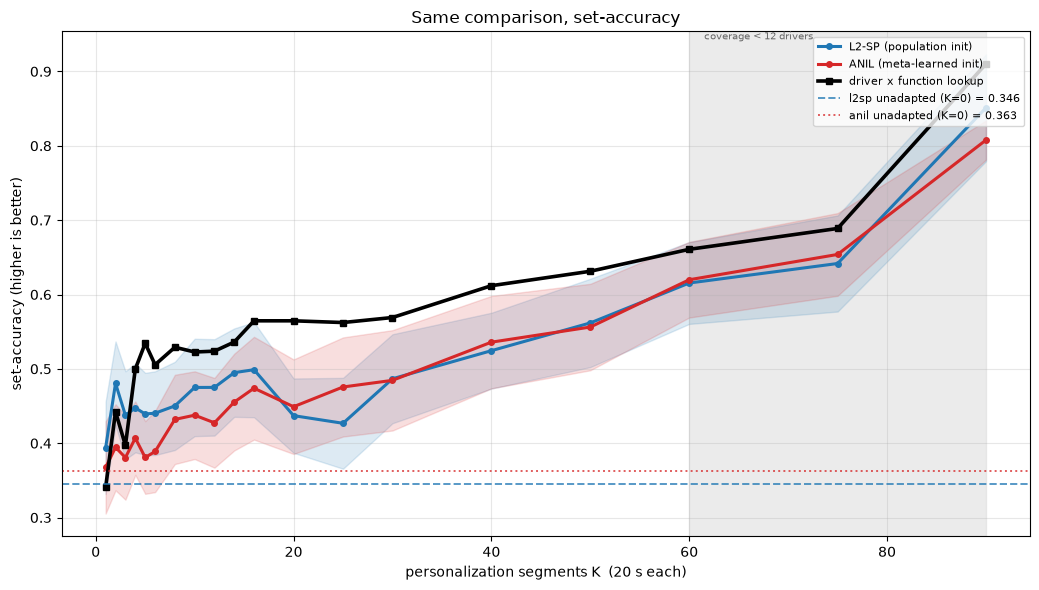

**Averaged within driver, then across drivers (K <= 60)**

,arm,set_mae,se,set_acc,n_drivers
0,L2-SP,1.0221,0.1188,0.4756,12
1,ANIL,1.0427,0.1292,0.4510,12
2,lookup,0.8275,0.1489,0.5292,12


In [4]:
fig, ax = plt.subplots(figsize=(10.5, 6))
draw(ax, "set_acc", "set-accuracy (higher is better)",
     "Same comparison, set-accuracy", invert_better=True)
plt.tight_layout(); save(fig, f"{FIGPREFIX}_k_curve_set_acc"); plt.show()

tbl = []
for name, df in [("L2-SP", A["l2sp"]), ("ANIL", A["anil"]), ("lookup", LK)]:
    sub = df[df.k <= K_CAP]
    pdm = sub.groupby("pid").set_mae.mean()
    pda = sub.groupby("pid").set_acc.mean()
    tbl.append({"arm": name, "set_mae": pdm.mean(),
                "se": pdm.std(ddof=1) / np.sqrt(len(pdm)),
                "set_acc": pda.mean(), "n_drivers": len(pdm)})
display(Markdown(f"**Averaged within driver, then across drivers (K <= {K_CAP})**"))
display(pd.DataFrame(tbl).round(4))

---
## 3. Per-driver curves

The cohort mean hides that these drivers are not remotely alike — per-driver floors
run from 0.79 to 2.32. A driver-level panel is what shows whether the arm difference
is a consistent small effect or two or three drivers carrying the mean.

[fig] c:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\latex\figures\arms_per_driver_set_mae.pdf


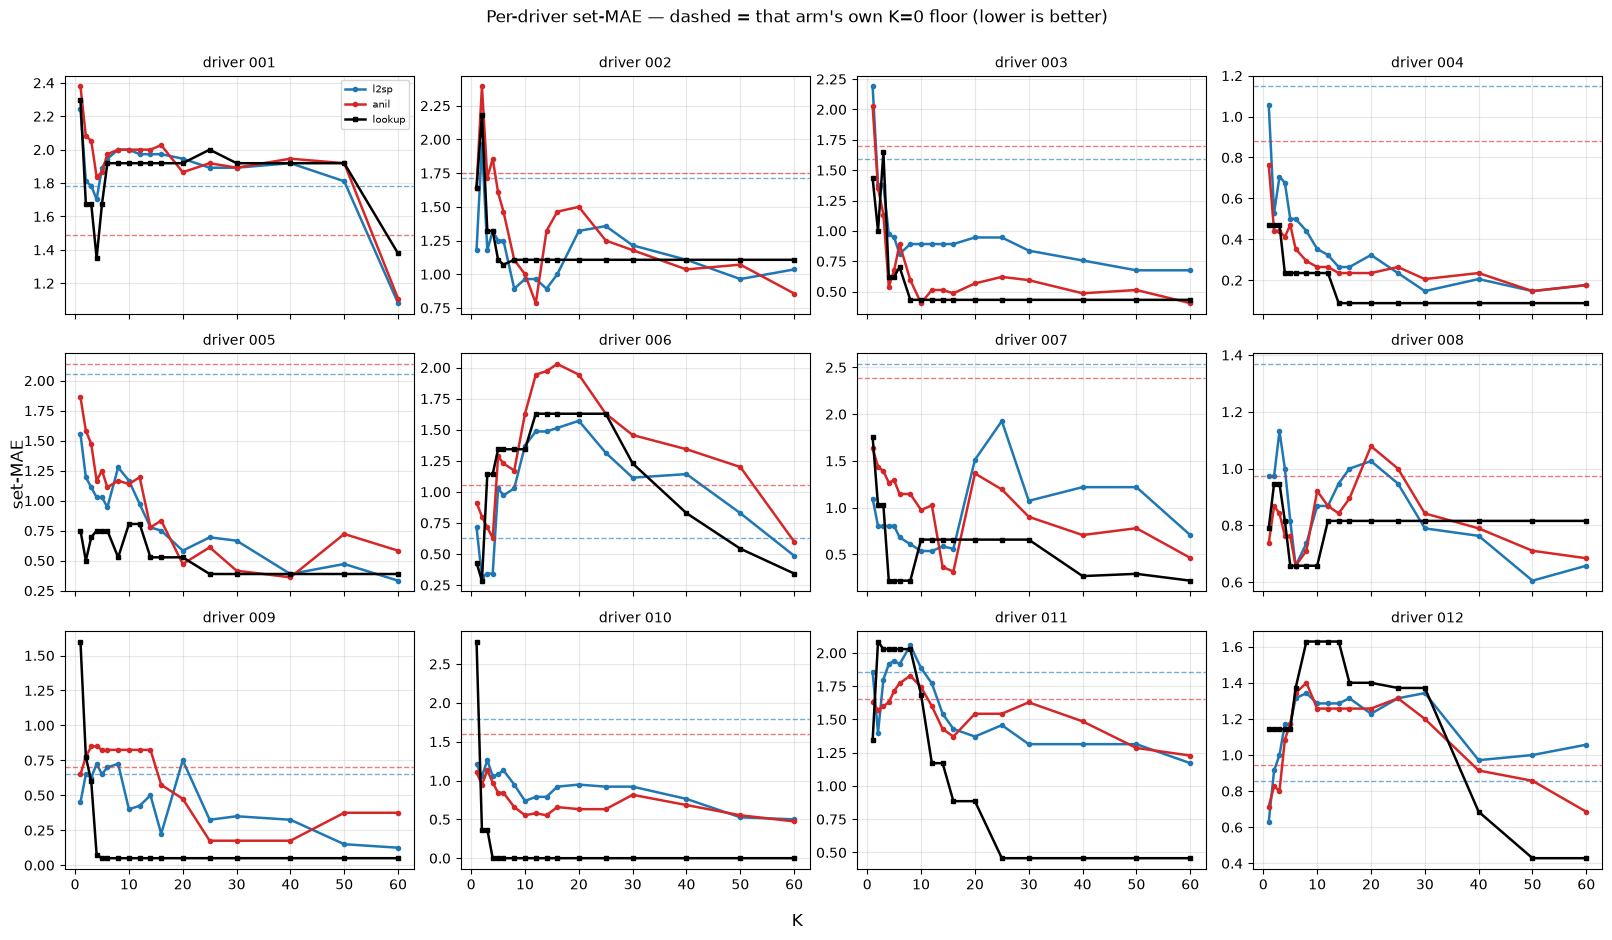

In [5]:
PIDS = sorted(A["l2sp"].pid.unique())



def per_driver_panels(col: str, base_col: str, ylabel: str, better: str,
                      pids=None, ncol: int = 4):
    """One panel per driver: both arms, the lookup, and each arm's own K=0 floor.

    Written once and called for both metrics. The dashed horizontal lines are the
    arm's OWN unadapted score for that driver -- not a shared floor -- because the
    two arms do not share one (section 4).

    Panels deliberately do NOT share a y-axis: per-driver difficulty spans roughly
    0.79 to 2.32 in set-MAE, so a common scale would compress most drivers into a
    band and hide the very within-driver movement these panels exist to show.
    """
    pids = list(pids if pids is not None else PIDS)
    nrow = int(np.ceil(len(pids) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.1 * ncol, 3.1 * nrow), sharex=True)
    for ax, pid in zip(axes.ravel(), pids):
        for arm in ARMS:
            g = A[arm][(A[arm].pid == pid) & (A[arm].k <= K_CAP)].sort_values("k")
            ax.plot(g.k, g[col], color=COL[arm], lw=1.8, marker="o", ms=3, label=arm)
            ax.axhline(g[base_col].iloc[0], ls="--", c=COL[arm], lw=1, alpha=.6)
        g = LK[(LK.pid == pid) & (LK.k <= K_CAP)].sort_values("k")
        ax.plot(g.k, g[col], color="k", lw=1.8, marker="s", ms=3, label="lookup")
        ax.set_title(f"driver {pid}", fontsize=10)
        ax.grid(alpha=.3)
    for ax in axes.ravel()[len(pids):]:
        ax.axis("off")
    axes.ravel()[0].legend(fontsize=7)
    fig.supxlabel("K"); fig.supylabel(ylabel)
    fig.suptitle(f"Per-driver {ylabel} — dashed = that arm's own K=0 floor "
                 f"({better} is better)", y=1.0)
    plt.tight_layout()
    save(fig, f"{FIGPREFIX}_per_driver_{col}")
    plt.show()

per_driver_panels("set_mae", "base_set_mae", "set-MAE", "lower")


The same panels in **set-accuracy**. Worth looking at both: set-MAE rewards moving
probability mass toward the right neighbourhood, accuracy only counts landing on the
exact level, so an arm can win one and not the other. Section 2's cohort table already
shows the two metrics do not rank the arms identically for every driver.

[fig] c:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\latex\figures\arms_per_driver_set_acc.pdf


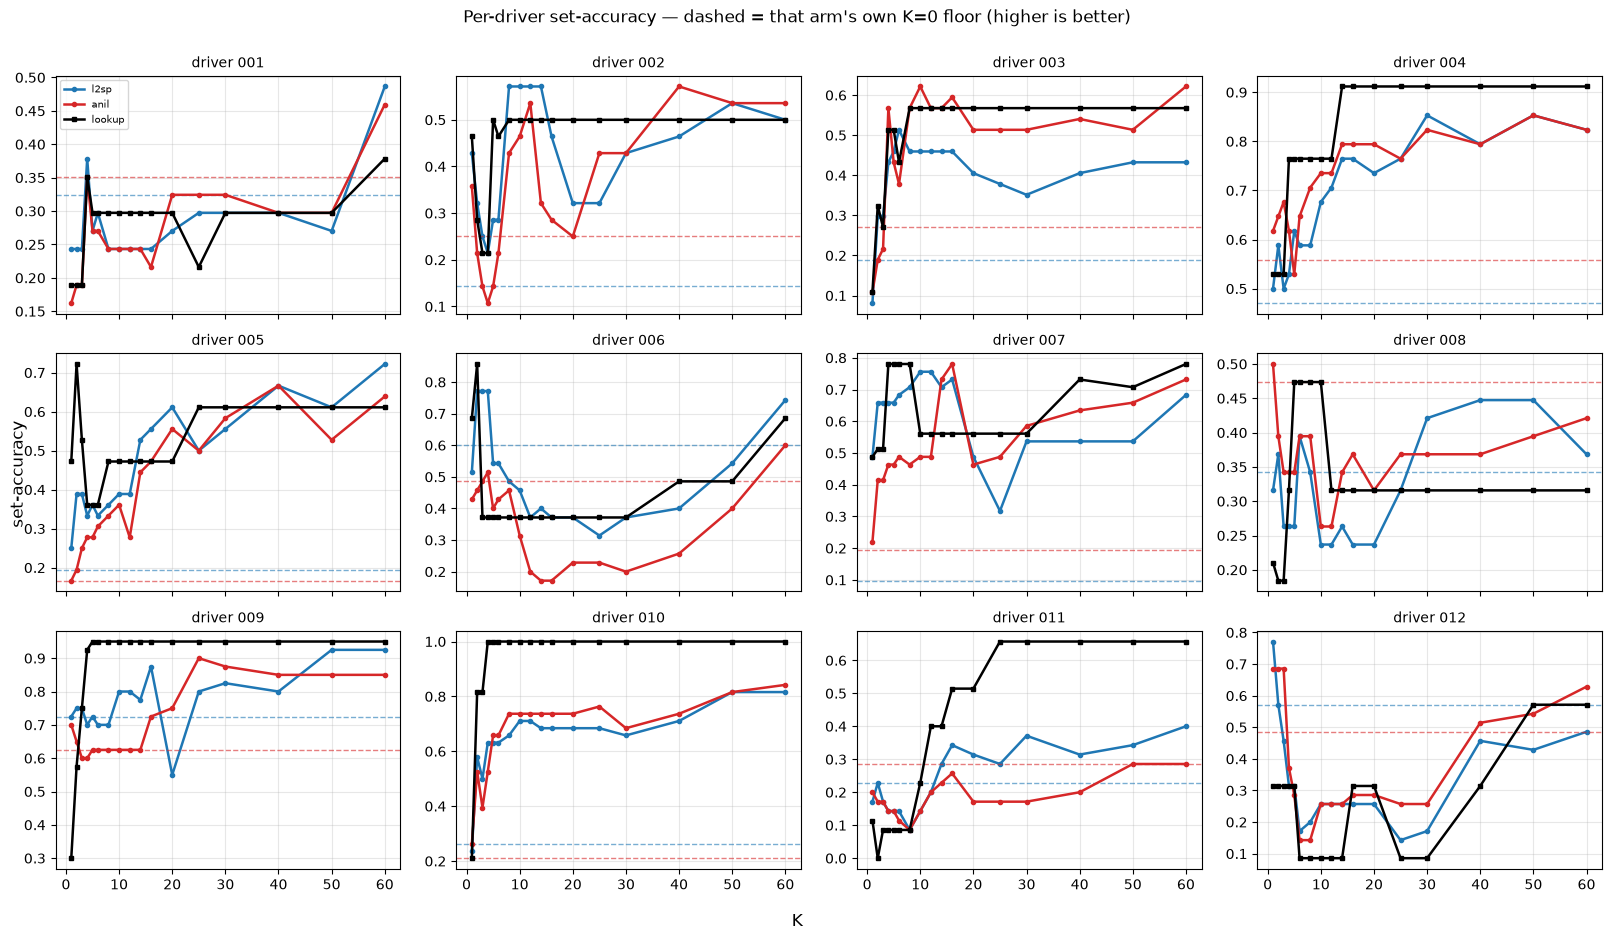

NameError: name 'P' is not defined

In [6]:
per_driver_panels("set_acc", "base_set_acc", "set-accuracy", "higher")

# Do the two metrics agree on WHICH drivers ANIL helps? A driver where they disagree
# is one where the predicted level moved closer without landing on the label more
# often -- worth knowing before quoting either metric alone.
mae_d = P[P.k <= K_CAP].groupby("pid").d_mae.mean()
acc_d = P[P.k <= K_CAP].groupby("pid").d_acc.mean()
agree = pd.DataFrame({"d_mae": mae_d, "d_acc": acc_d})
agree["anil_better_mae"] = agree.d_mae < 0
agree["anil_better_acc"] = agree.d_acc > 0
agree["agree"] = agree.anil_better_mae == agree.anil_better_acc
display(Markdown("**Do set-MAE and set-accuracy agree per driver?**"))
display(agree.round(4))
print(f"the two metrics agree on {agree.agree.sum()}/{len(agree)} drivers; "
      f"disagreements: {sorted(agree.index[~agree.agree])}")